chi^2_min = 19.399184197569127
reduced chi^2 = 1.2124490123480705
P(chi^2_min, DoF) = 0.24850708178348965


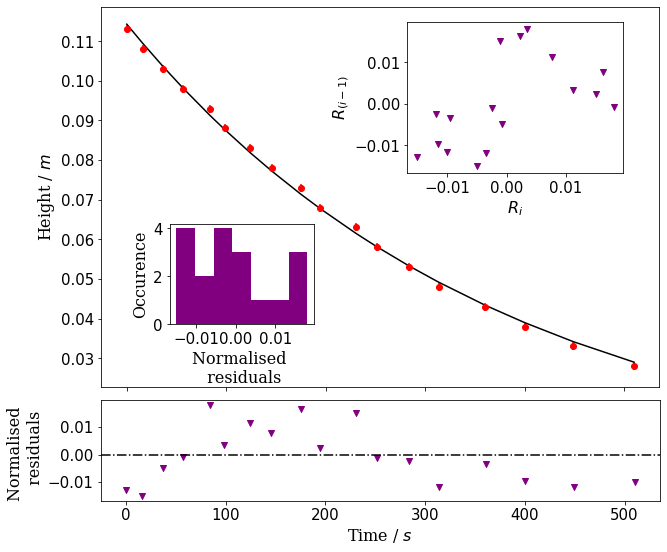

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy
import scipy.optimize
import scipy.stats
import pandas as pd
import matplotlib.ticker as ticker

ff = 'serif'
fs = 16
plt.rc('xtick', labelsize=15) 
plt.rc('ytick', labelsize=15) 


sp = pd.read_excel('Video run 1 -h113.xlsx')
x_values = sp['time '].values 
x_errors = sp['time_error'].values
y_values = (sp['height '].values )/1000
y_errors = sp['height_error'].values /10000
plt.rcParams['figure.figsize'] = [10,7]
assert len(y_values) == len(x_values)
assert len(y_errors) == len(y_values)

fig, ax = plt.subplots()

def model_function(x, *params):
    return params[0]*(numpy.exp(params[1]*x))


initial_values = numpy.array([1.1, 0.0]) # Initial guess for fit parameters

def chi_squared(model_params, model, x_data, y_data, y_err):
    return numpy.sum(((y_data - model(x_data, *model_params))/y_err)**2) # Note the `*model_params' here!

degrees_of_freedom = x_values.size - initial_values.size
popt, cov = scipy.optimize.curve_fit(model_function, # function to fit
                                     x_values, # x data
                                     y_values, # y data
                                     sigma=y_errors, # array of error bars for the fit
                                     absolute_sigma=True, # errors bars DO represent 1 std error
                                     p0=initial_values, # starting point for fit
                                     check_finite=True) # raise ValueError if NaN encountered (don't allow errors to pass)

#print('Optimised parameters = ', popt, '\n')
#print('Covariance matrix = \n', cov)


plt.figure(1)

plt.errorbar(x_values, 
             y_values, 
             yerr=y_errors, 
             marker='o', 
             linestyle='None',
             color = 'r')
ax.set_xticklabels([])
# Axis labels
ax.set_ylabel('Height / $m$', family = ff, fontsize = fs)
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.01))

# Generate best fit using model function and best fit parameters, and add to plot
plt.plot(x_values, 
         model_function(x_values, *popt), 
         color='black')

residuals = (-1*model_function(x_values, *popt) + y_values) / 0.1 #it is NORMALISED 
plt.figure(1).add_axes((0.124,-0.1,0.7769,0.2))
plt.scatter(x_values, residuals, marker = 'v', color = 'purple')
plt.xlabel('Time / $s$', family = ff, fontsize = fs)
plt.ylabel('Normalised \n residuals', family = ff, fontsize = fs)
plt.axhline(y=0, color= 'black', linestyle='-.')


#lag plot 
plt.figure(1).add_axes((0.55,0.55,0.3,0.3))

R_i_minus = residuals[:-1]
R_i = residuals[1:]



plt.scatter(R_i, R_i_minus, marker = 'v', color = 'purple')
plt.ylabel('$R_{(i-1)}$', family = ff, fontsize = fs)
plt.xlabel('$R_{i}$', family = ff, fontsize = fs)

plt.figure(1).add_axes((0.22,0.25,0.2,0.2))
plt.hist(residuals, bins = 7, color ='purple')
plt.xlabel('Normalised \n residuals', family = ff, fontsize = fs)
plt.ylabel('Occurence', family = ff, fontsize = fs)


chi_squared_min = chi_squared(popt, model_function, x_values, y_values, y_errors)
print('chi^2_min = {}'.format(chi_squared_min))
print('reduced chi^2 = {}'.format(chi_squared_min/degrees_of_freedom))
print('P(chi^2_min, DoF) = {}'.format(scipy.stats.chi2.sf(chi_squared_min, degrees_of_freedom)))

#print('h_0 = {} ?'.format(popt[0]))
#print('lambda = {} units?'.format(popt[1]))

#fig.savefig('MethodB1FINAL2', dpi=fig.dpi, bbox_inches='tight', pad_inches=0.5)

In [22]:
D = numpy.sum((R_i - R_i_minus)**2)/numpy.sum(R_i**2)

print('Curly D =' + str(D))

Curly D =0.9477338104300799


[5.15779513e-04 2.83913780e-05]
optimised parameter[0] = (0.1142929084755099 +/- 0.000515779512885744) units
optimised parameter[1] = (-0.0026883931694596814 +/- 2.8391377969594543e-05) units


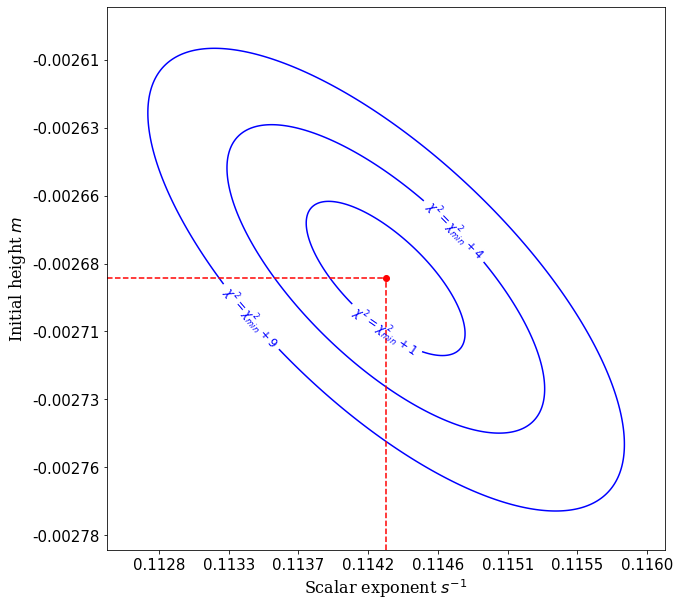

In [25]:
popt_errs = numpy.sqrt(numpy.diag(cov))
print(popt_errs)
for i, (val, err) in enumerate(zip(popt, popt_errs)):
    print('optimised parameter[{}] = ({} +/- {}) units'.format(i, val, err))
    assert(popt.size == 2) # contour plot only 'works' for 2D parameter space!

extent = 3.5 # standard errors
n_points = 300 # mesh density         

p0_range = extent * popt_errs[0]
p1_range = extent * popt_errs[1]

# Generate grid and data
p0_axis = numpy.linspace(popt[0]-p0_range, popt[0]+p0_range, num=n_points)
p1_axis = numpy.linspace(popt[1]-p1_range, popt[1]+p1_range, num=n_points)
plot_data = numpy.zeros((n_points, n_points))

for j, p1_val in enumerate(p1_axis): 
    for i, p0_val in enumerate(p0_axis): # Nested loops for 'clarity'...
        plot_data[j][i] = chi_squared([p0_val, p1_val], # function evaluated n_points*n_points times!
                                      model_function, 
                                      x_values, 
                                      y_values, 
                                      y_errors)
assert(popt.size == 2) # contour plot only 'works' for 2D parameter space!

X, Y = numpy.meshgrid(p0_axis, p1_axis, indexing='xy')
contour_data = plot_data - chi_squared_min

levels = [1, 4, 9] # Contour levels in delta chi-squared of 1, 4 & 9 correspond to 1, 2 & 3 standard errors
plt.figure(figsize=(10,10))

#Plot and label contours: (comment out labelling to remove text over contours)
contour_plot = plt.contour(X, Y, contour_data, levels=levels, colors='b', origin='lower')
plt.clabel(contour_plot, levels, fontsize=12, inline=1, fmt=r'$\chi^2 = \chi^2_{min}+%1.0f$') 

plt.xlabel('Scalar exponent $ s^{-1} $',family = ff, fontsize = fs) 
plt.ylabel('Initial height $m$', family = ff, fontsize = fs)

import matplotlib.ticker as ticker # Allows you to modify the tick markers to 
xtick_spacing = p0_range/4         # assess the errors from the chi-squared 
ytick_spacing = p1_range/4         # contour plots - set as appropriate
 
ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MultipleLocator(xtick_spacing))
ax.xaxis.set_major_formatter('{x:.4f}') # 2 decimal places - may or may not be appropriate!

ax.yaxis.set_major_locator(ticker.MultipleLocator(ytick_spacing))
ax.yaxis.set_major_formatter('{x:.5f}') # 2 decimal places - may or may not be appropriate!

# Add in best fit point and dashed lines to the axes
plt.plot(popt[0], popt[1], 'ro') 
plt.plot((popt[0], popt[0]), (p1_axis[0], popt[1]), linestyle='--', color='r')
plt.plot((p0_axis[0], popt[0]), (popt[1], popt[1]), linestyle='--', color='r')
plt.figure(1)
fig.savefig('MethodB1surface1', dpi=fig.dpi, bbox_inches='tight', pad_inches=0.2)